In [1]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import glob
from spark_session import get_spark_session

print("Importaciones completas.")

Importaciones completas.


In [2]:
# --- 2. PARÁMETROS DE CONFIGURACIÓN ---

# Ruta LAPTOP (Host) - Para que el Driver lea los archivos
HOST_DATA_PATH = "./../../data" 
# Ruta DENTRO de los contenedores Docker (como en docker-compose.yml)
CONTAINER_DATA_PATH = "/opt/spark/data"

# Ruta base donde se guardarán los resultados (en el Host, para la limpieza inicial)
OUTPUT_HOST_PATH = os.path.join(HOST_DATA_PATH, "rings-view")
# Ruta base donde los workers escribirán (en el Contenedor)
OUTPUT_CONTAINER_PATH = os.path.join(CONTAINER_DATA_PATH, "rings-view")

# Límite de imágenes a procesar (None para todas)
IMAGE_LIMIT = None

# Color de las líneas de los anillos (BGR format)
RING_COLOR = (0, 255, 0)  # Verde
# Grosor de las líneas
RING_THICKNESS = 2

In [3]:
# --- 3. INICIALIZAR SESIÓN DE SPARK ---
print("Iniciando SparkSession en modo distribuido...")
spark = get_spark_session("TreeRingVisualization (Distributed)")

sc = spark.sparkContext
print("\n--- SparkSession Iniciada --- ✅")
print(f"Spark Version: {sc.version}")
print(f"Master: {sc.master}")
print(f"UI Web: {sc.uiWebUrl}")

Iniciando SparkSession en modo distribuido...
Attempting to connect to master at: spark://localhost:7077
Will announce driver host IP as: 172.26.0.1
Check: IP 172.26.0.1 resolves locally.


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/15 21:38:31 WARN Utils: Your hostname, archlinux, resolves to a loopback address: 127.0.0.1; using 192.168.1.8 instead (on interface wlp0s20f3)
25/11/15 21:38:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/15 21:38:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable



--- Connection Successful! --- ✅
SparkSession object: <pyspark.sql.session.SparkSession object at 0x7f57e8b3e680>
SparkContext object: <SparkContext master=spark://localhost:7077 appName=TreeRingVisualization (Distributed)>
Spark version in use: 4.0.1

--- SparkSession Iniciada --- ✅
Spark Version: 4.0.1
Master: spark://localhost:7077
UI Web: http://172.26.0.1:4040


In [4]:
# --- 4. FUNCIONES AUXILIARES ---

def get_image_files(raw_path, limit=None):
    """
    Escanea la carpeta 'raw' y devuelve una lista de nombres de archivo de imagen.
    """
    try:
        all_files = [f for f in os.listdir(raw_path) if f.lower().endswith('.png')]
        all_files.sort()
        
        if limit is not None:
            print(f"Se encontraron {len(all_files)} imágenes. Procesando las primeras {limit}.")
            return all_files[:limit]
        else:
            print(f"Se encontraron y procesarán {len(all_files)} imágenes.")
            return all_files
            
    except FileNotFoundError:
        print(f"Error: No se encontró el directorio 'raw' en {raw_path}")
        return []

def load_ring_annotations(json_path):
    """
    Carga el archivo JSON con las anotaciones de anillos.
    Retorna una lista de anillos, donde cada anillo es una lista de puntos.
    """
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        rings = []
        for shape in data.get('shapes', []):
            points = shape.get('points', [])
            if points:
                # Convertir puntos a array de numpy con tipo int32
                ring_points = np.array(points, dtype=np.int32)
                rings.append(ring_points)
        
        return rings
    
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo JSON en {json_path}")
        return []
    except json.JSONDecodeError as e:
        print(f"Error decodificando JSON {json_path}: {e}")
        return []
    except Exception as e:
        print(f"Error cargando JSON {json_path}: {e}")
        return []

In [5]:
# --- 5. WORKER PROCESSING LOGIC ---

def process_ring_visualization(image_name, base_data_path, output_base_path, ring_color, ring_thickness):
    """
    Main function that will run in parallel on each worker.
    Takes an image name, loads it along with its ring annotations,
    draws the rings on the image, and saves the result.
    
    Args:
        image_name: Name of the image file (e.g., 'F02a.png')
        base_data_path: Base path to data directory (inside container)
        output_base_path: Base path for output (inside container)
        ring_color: BGR color tuple for ring lines
        ring_thickness: Thickness of ring lines
    
    Returns:
        Tuple of (image_name, status_message)
    """
    try:
        # --------------------------------------------------
        # 1. Setup paths
        # --------------------------------------------------
        image_name_no_ext = os.path.splitext(image_name)[0]
        
        # Input paths
        image_path = os.path.join(base_data_path, 'raw', image_name)
        json_path = os.path.join(base_data_path, 'ring_annotations', f'{image_name_no_ext}.json')
        
        # Output path
        output_path = os.path.join(output_base_path, image_name)
        
        # --------------------------------------------------
        # 2. Load image
        # --------------------------------------------------
        img = cv2.imread(image_path)
        if img is None:
            return (image_name, "ERROR: Could not read image")
        
        # --------------------------------------------------
        # 3. Load ring annotations
        # --------------------------------------------------
        rings = load_ring_annotations(json_path)
        if not rings:
            return (image_name, f"WARNING: No rings found in JSON (or JSON not found)")
        
        # --------------------------------------------------
        # 4. Draw rings on image
        # --------------------------------------------------
        # Create a copy to draw on
        result_img = img.copy()
        
        rings_drawn = 0
        for ring_points in rings:
            # Draw polylines connecting all points in the ring
            # isClosed=True to close the ring
            cv2.polylines(
                result_img, 
                [ring_points], 
                isClosed=True, 
                color=ring_color, 
                thickness=ring_thickness
            )
            rings_drawn += 1
        
        # --------------------------------------------------
        # 5. Save result
        # --------------------------------------------------
        # Ensure output directory exists
        os.makedirs(output_base_path, exist_ok=True)
        
        # Save the image with rings drawn
        cv2.imwrite(output_path, result_img)
        
        return (image_name, f"SUCCESS: {rings_drawn} rings drawn and saved")
    
    except Exception as e:
        # Catch any unexpected errors
        return (image_name, f"ERROR: {str(e)}")

In [6]:
# --- 6. SPARK PIPELINE EXECUTION ---

print("=" * 60)
print("Starting Spark Ring Visualization Pipeline")
print("=" * 60)

# ------------------------------------------------------------------------------
# STEP 0: Prepare output directory with proper permissions
# ------------------------------------------------------------------------------
print("\n[0/5] Preparing output directory...")

# Clean and recreate output directory
if os.path.exists(OUTPUT_HOST_PATH):
    print(f"  → Cleaning previous output: {OUTPUT_HOST_PATH}")
    shutil.rmtree(OUTPUT_HOST_PATH)

# Create with proper permissions for Docker containers
os.makedirs(OUTPUT_HOST_PATH, exist_ok=True)
os.chmod(OUTPUT_HOST_PATH, 0o777)
print(f"  ✓ Output directory ready: {OUTPUT_HOST_PATH}")

# ------------------------------------------------------------------------------
# STEP 1: Get list of images to process (Driver-side)
# ------------------------------------------------------------------------------
print("\n[1/5] Scanning for image files (Driver-side)...")

image_files = get_image_files(os.path.join(HOST_DATA_PATH, 'raw'), limit=IMAGE_LIMIT)
if not image_files:
    raise ValueError("No images found to process. Aborting.")

print(f"  ✓ Found {len(image_files)} image(s) to process")

# ------------------------------------------------------------------------------
# STEP 2: Create RDD for distributed processing
# ------------------------------------------------------------------------------
print("\n[2/5] Creating RDD for parallel processing...")

image_rdd = sc.parallelize(image_files)
print(f"  ✓ RDD created with {image_rdd.getNumPartitions()} partition(s)")

# ------------------------------------------------------------------------------
# STEP 3: Define worker function and execute transformations
# ------------------------------------------------------------------------------
print("\n[3/5] Executing distributed ring visualization...")

def run_ring_visualization(image_name):
    """
    Wrapper function that will run on each Spark worker.
    Passes container paths (not host paths) to the processing function.
    """
    return process_ring_visualization(
        image_name,
        CONTAINER_DATA_PATH,      # Path inside Docker container
        OUTPUT_CONTAINER_PATH,     # Path inside Docker container
        RING_COLOR,
        RING_THICKNESS
    )

# Execute the transformation (map) and action (collect)
results = image_rdd.map(run_ring_visualization).collect()

print(f"  ✓ Processing completed!")

# ------------------------------------------------------------------------------
# STEP 4: Display execution results
# ------------------------------------------------------------------------------
print("\n[4/5] Execution Summary:")
print("-" * 60)

success_count = 0
error_count = 0
warning_count = 0

for image_name, status in results:
    if "SUCCESS" in status:
        status_icon = "✓"
        success_count += 1
    elif "WARNING" in status:
        status_icon = "⚠"
        warning_count += 1
    else:
        status_icon = "✗"
        error_count += 1
    
    print(f"  {status_icon} {image_name}: {status}")

print("-" * 60)
print(f"\nResults: {success_count} successful, {warning_count} warnings, {error_count} errors")
print("\n✅ Pipeline execution completed!")
print("=" * 60)

Starting Spark Ring Visualization Pipeline

[0/5] Preparing output directory...
  ✓ Output directory ready: ./../../data/rings-view

[1/5] Scanning for image files (Driver-side)...
Se encontraron y procesarán 64 imágenes.
  ✓ Found 64 image(s) to process

[2/5] Creating RDD for parallel processing...
  ✓ RDD created with 6 partition(s)

[3/5] Executing distributed ring visualization...


  ✓ Processing completed!

[4/5] Execution Summary:
------------------------------------------------------------
  ✓ F02a.png: SUCCESS: 23 rings drawn and saved
  ✓ F02b.png: SUCCESS: 22 rings drawn and saved
  ✓ F02c.png: SUCCESS: 22 rings drawn and saved
  ✓ F02d.png: SUCCESS: 20 rings drawn and saved
  ✓ F02e.png: SUCCESS: 20 rings drawn and saved
  ✓ F03a.png: SUCCESS: 24 rings drawn and saved
  ✓ F03b.png: SUCCESS: 23 rings drawn and saved
  ✓ F03c.png: SUCCESS: 24 rings drawn and saved
  ✓ F03d.png: SUCCESS: 21 rings drawn and saved
  ✓ F03e.png: SUCCESS: 21 rings drawn and saved
  ✓ F04a.png: SUCCESS: 24 rings drawn and saved
  ✓ F04b.png: SUCCESS: 23 rings drawn and saved
  ✓ F04c.png: SUCCESS: 21 rings drawn and saved
  ✓ F04d.png: SUCCESS: 21 rings drawn and saved
  ✓ F04e.png: SUCCESS: 21 rings drawn and saved
  ✓ F07a.png: SUCCESS: 24 rings drawn and saved
  ✓ F07b.png: SUCCESS: 23 rings drawn and saved
  ✓ F07c.png: SUCCESS: 23 rings drawn and saved
  ✓ F07d.png: SUCCESS: 


Mostrando resultados de las primeras 6 imágenes procesadas...


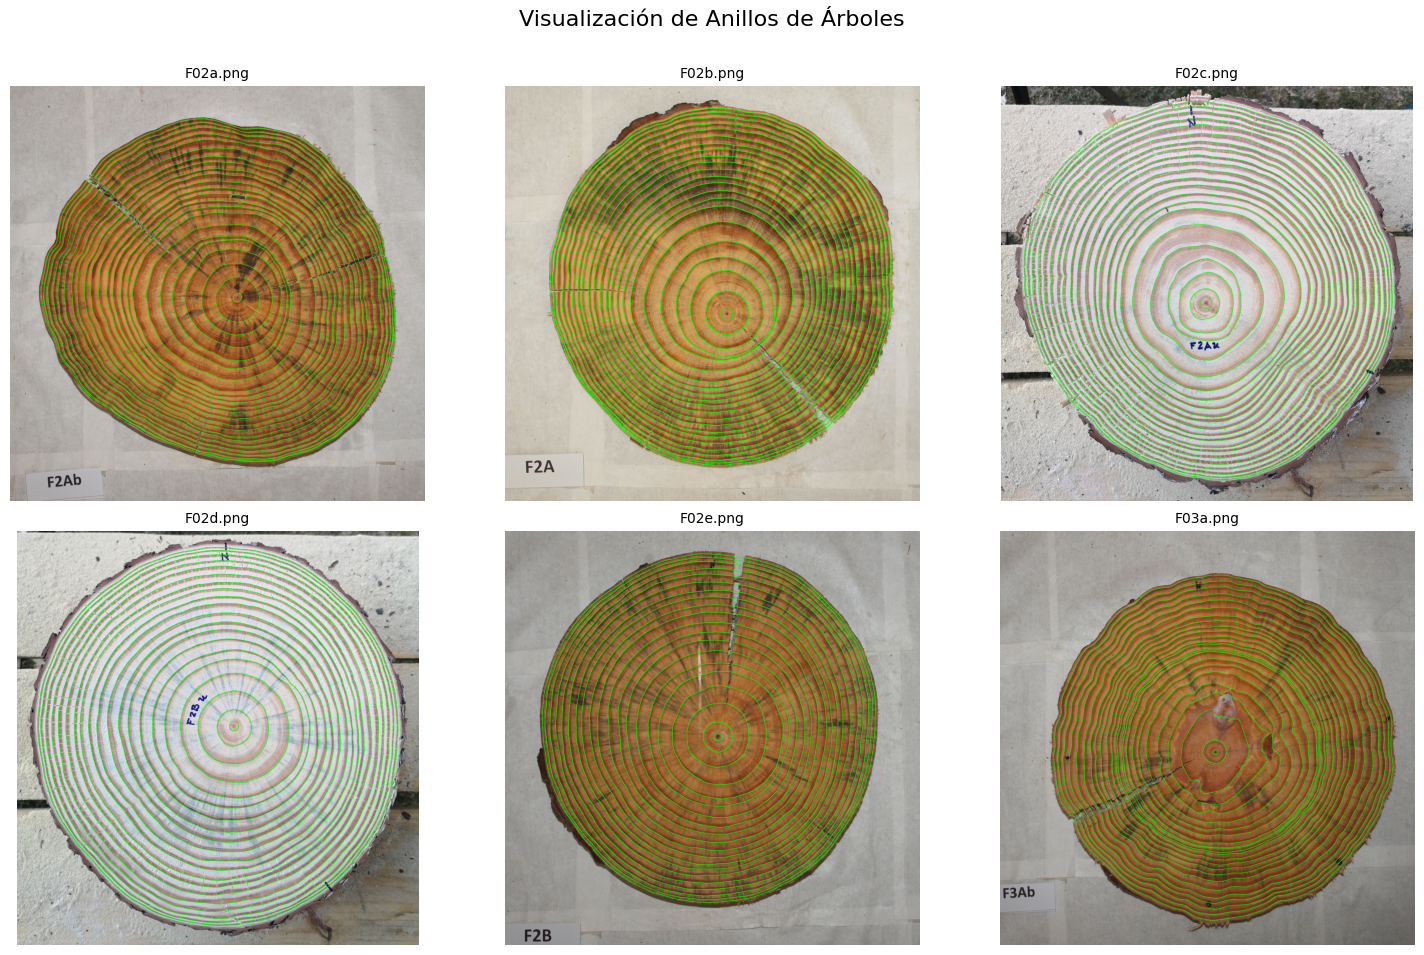


✓ Mostrando 6 imágenes con anillos dibujados


In [7]:
# --- 7. VERIFICACIÓN DE RESULTADOS ---

print("\nMostrando resultados de las primeras 6 imágenes procesadas...")

# Obtener las primeras 6 imágenes procesadas exitosamente
successful_images = [img for img, status in results if "SUCCESS" in status][:6]

if not successful_images:
    print("No se encontraron imágenes procesadas exitosamente.")
else:
    # Crear una grilla para mostrar las imágenes
    n_images = len(successful_images)
    n_cols = 3
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    fig.suptitle('Visualización de Anillos de Árboles', fontsize=16)
    
    # Aplanar el array de ejes si hay múltiples filas
    if n_rows > 1:
        axes = axes.flatten()
    elif n_images == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes if n_rows > 1 else axes):
        if i < len(successful_images):
            # Cargar la imagen generada
            img_path = os.path.join(OUTPUT_HOST_PATH, successful_images[i])
            img = cv2.imread(img_path)
            
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
                ax.set_title(successful_images[i], fontsize=10)
                ax.axis('off')
            else:
                ax.text(0.5, 0.5, 'Error cargando imagen', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.axis('off')
        else:
            # Ocultar ejes vacíos
            ax.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    print(f"\n✓ Mostrando {len(successful_images)} imágenes con anillos dibujados")

In [8]:
# --- 8. DETENER LA SESIÓN DE SPARK ---
print("Deteniendo SparkSession...")
spark.stop()
print("Sesión detenida.")

Deteniendo SparkSession...
Sesión detenida.
